# Best Model Training and Evaluation (E6 Configuration)

This notebook implements the entire pipeline using the best model configuration (Experiment 6). For other experiments, please refer to the github repository


In [1]:
import os
import sys
import json
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import pandas as pd
import numpy as np
import cv2
import albumentations as A
import matplotlib.pyplot as plt
import random


Patients:   0%|          | 0/110 [00:00<?, ?it/s]

Patients: 100%|██████████| 110/110 [00:36<00:00,  3.00it/s]


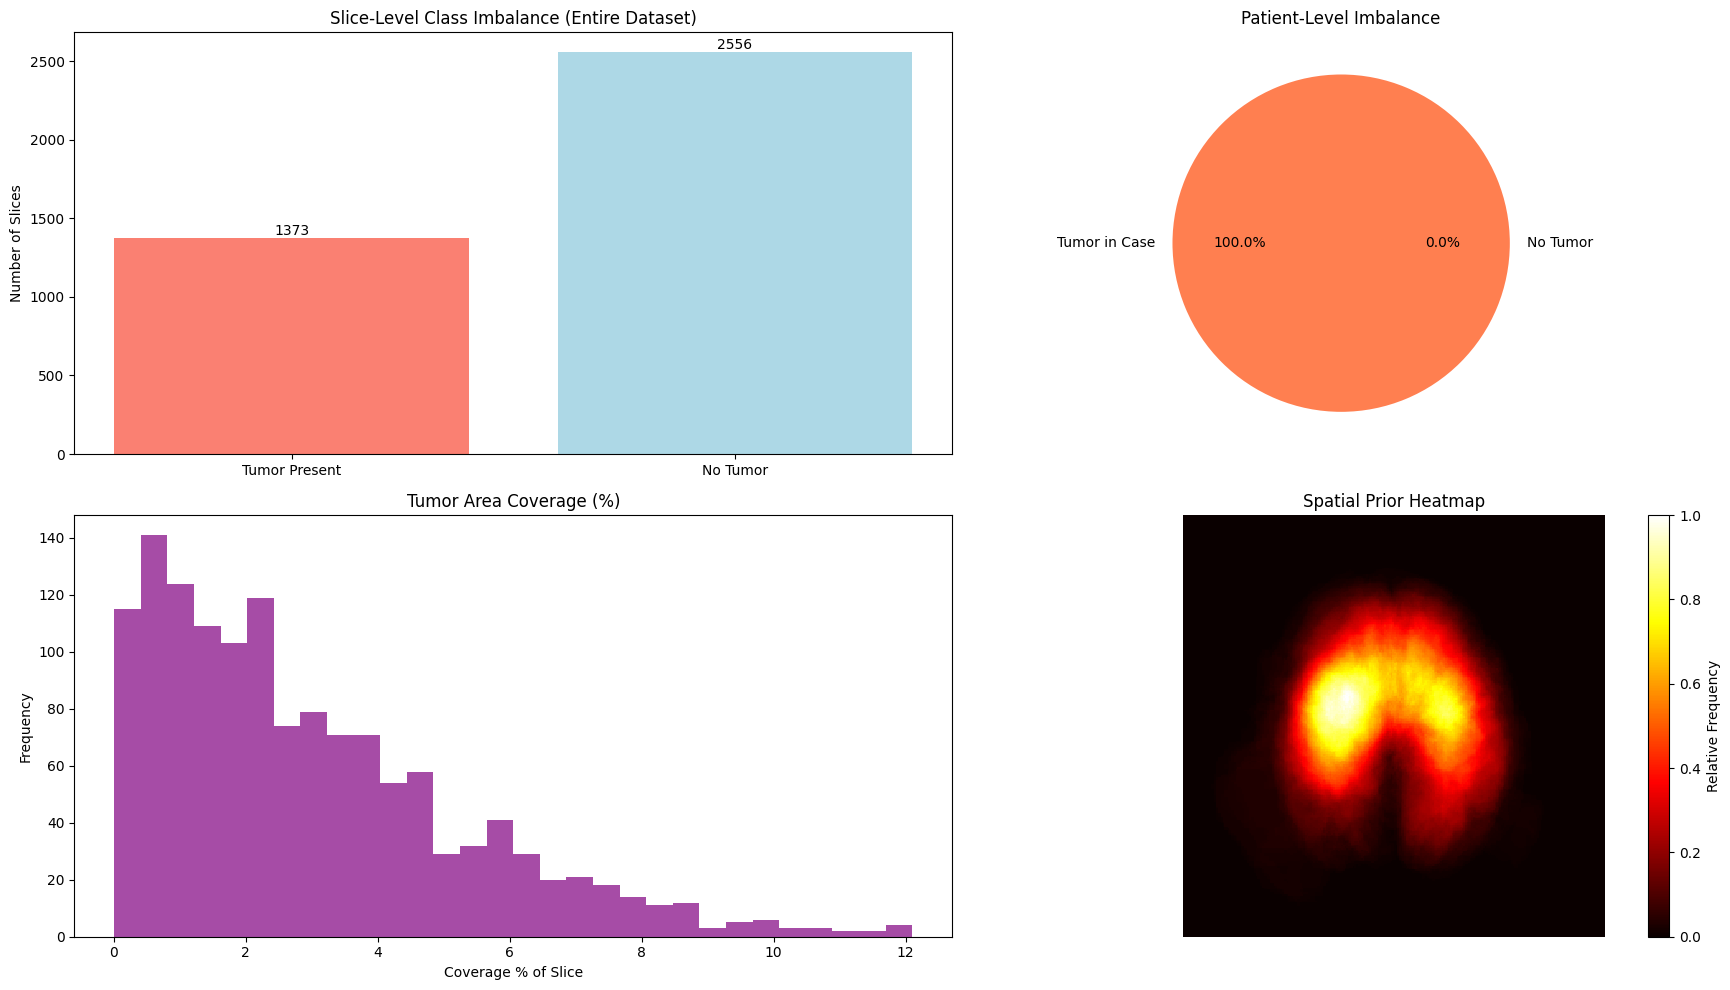

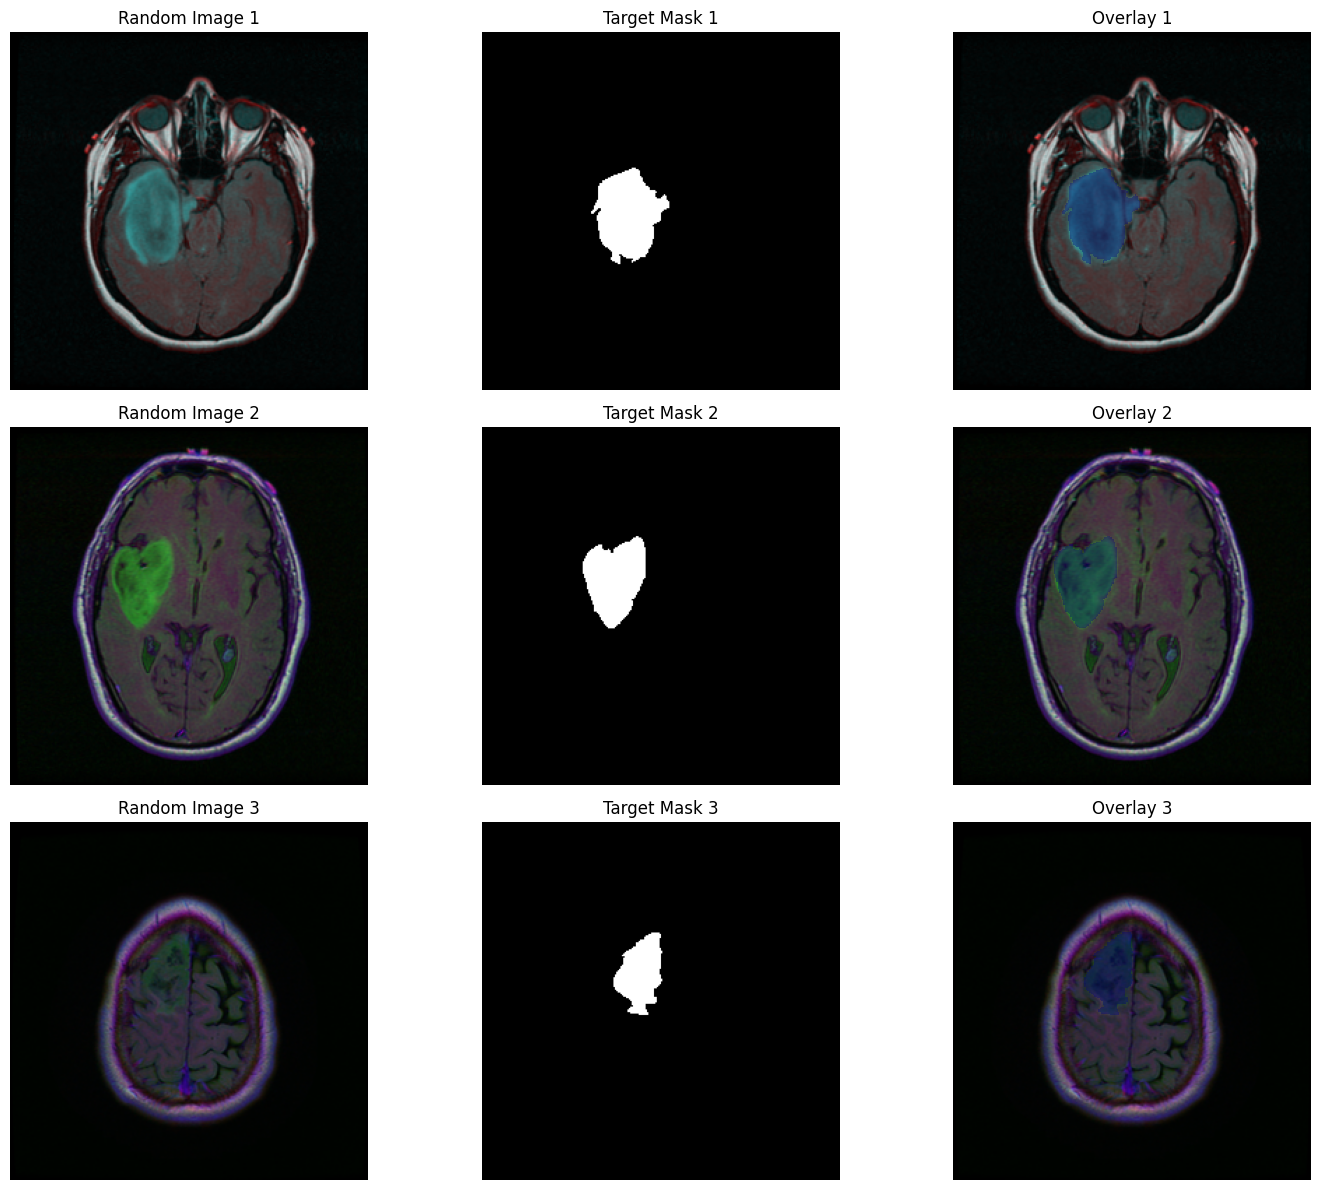

Total Patients Analyzed: 110
Total Slices Scanned: 3929
Imbalance Ratio: 1.86 negative slices for every positive slice


In [2]:
# Data exploration
dataset_path = "../data/raw/kaggle_3m"

positive_masks = 0
negative_masks = 0
tumor_coverages = []
heatmap = None

# Collect patient folders
patient_folders = [f for f in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, f))]
patient_tumor_counts = {p: 0 for p in patient_folders}

image_paths = []

for patient in tqdm(patient_folders, desc="Patients"):
    patient_path = os.path.join(dataset_path, patient)
    files = os.listdir(patient_path)
    
    # We only care about mask files to determine tumor presence
    masks = [f for f in files if f.endswith("_mask.tif")]
    
    for mask_file in masks:
        mask_path = os.path.join(patient_path, mask_file)
        img_path = mask_path.replace("_mask.tif", ".tif")
        
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None: continue
            
        # Register image path for random sampling
        image_paths.append(img_path)
        
        # Calculate how much of the slice is covered by the tumor
        coverage = (mask > 0).mean() * 100
        
        if coverage > 0:
            positive_masks += 1
            tumor_coverages.append(coverage)
            patient_tumor_counts[patient] += 1
            
            # --- Spatial Heatmap Aggregation ---
            if heatmap is None:
                heatmap = np.zeros(mask.shape, dtype=np.float32)
            # Add mask presence to the heatmap 
            heatmap += (mask > 0).astype(np.float32)
        else:
            negative_masks += 1

plt.figure(figsize=(18, 10))

# 1. Slice-Level Class Imbalance
plt.subplot(2, 2, 1)
counts = [positive_masks, negative_masks]
plt.bar(['Tumor Present', 'No Tumor'], counts, color=['salmon', 'lightblue'])
plt.title("Slice-Level Class Imbalance (Entire Dataset)")
plt.ylabel("Number of Slices")
for i, v in enumerate(counts):
    plt.text(i, v, str(v), ha='center', va='bottom')

# 2. Patient-Level Distribution
plt.subplot(2, 2, 2)
patients_with_tumor = sum(1 for v in patient_tumor_counts.values() if v > 0)
patients_without_tumor = len(patient_tumor_counts) - patients_with_tumor
plt.pie([patients_with_tumor, patients_without_tumor], 
        labels=['Tumor in Case', 'No Tumor'], autopct='%1.1f%%', colors=['coral', 'lightgreen'])
plt.title("Patient-Level Imbalance")

# 3. Tumor Size Distribution
plt.subplot(2, 2, 3)
plt.hist(tumor_coverages, bins=30, color='purple', alpha=0.7)
plt.title("Tumor Area Coverage (%)")
plt.xlabel("Coverage % of Slice")
plt.ylabel("Frequency")

# 4. Spatial Heatmap
plt.subplot(2, 2, 4)
if heatmap is not None:
    heatmap_norm = heatmap / np.max(heatmap)
    plt.imshow(heatmap_norm, cmap='hot', interpolation='nearest')
    plt.colorbar(label='Relative Frequency')
    plt.title("Spatial Prior Heatmap")
    plt.axis("off")

plt.tight_layout()
plt.show()

random_samples = random.sample(image_paths, 3)
plt.figure(figsize=(15, 12))

for i, img_path in enumerate(random_samples, start=1):
    mask_path = img_path.replace(".tif", "_mask.tif")
    
    img = cv2.imread(img_path)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Raw Image
    plt.subplot(3, 3, 3 * (i - 1) + 1)
    plt.imshow(img_rgb)
    plt.title(f"Random Image {i}")
    plt.axis("off")

    # Target Mask
    plt.subplot(3, 3, 3 * (i - 1) + 2)
    plt.imshow(mask, cmap="gray")
    plt.title(f"Target Mask {i}")
    plt.axis("off")

    # Translucent Overlay
    plt.subplot(3, 3, 3 * (i - 1) + 3)
    plt.imshow(img_rgb)
  
    masked_data = np.ma.masked_where(mask == 0, mask)
    plt.imshow(masked_data, cmap="jet", alpha=0.35, interpolation='none')
    plt.title(f"Overlay {i}")
    plt.axis("off")

plt.tight_layout()
plt.show()


print(f"Total Patients Analyzed: {len(patient_folders)}")
print(f"Total Slices Scanned: {positive_masks + negative_masks}")
if positive_masks > 0:
    print(f"Imbalance Ratio: {negative_masks / positive_masks:.2f} negative slices for every positive slice")



In [3]:
# Configurations of the best experiment
IMAGE_SIZE = 256
BATCH_SIZE = 8
LEARNING_RATE = 1e-4
NUM_EPOCHS = 20
EXPERIMENT_ID = "E6"
MODEL_TYPE = "unet" ## with batch normalization
LOSS_TYPE = "bce"

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

TRAIN_CSV = "data/processed/train.csv"
VAL_CSV = "data/processed/val.csv"
TEST_CSV = "data/processed/test.csv"
CHECKPOINTS_DIR = "outputs/checkpoints"
EVALUATION_DIR = "outputs/evaluation"

os.makedirs(CHECKPOINTS_DIR, exist_ok=True)
os.makedirs(os.path.join(EVALUATION_DIR, EXPERIMENT_ID), exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [4]:
# Dataset Definition
class LGGSegmentationDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.data_info = pd.read_csv(csv_file)
        self.transform = transform

    def __len__(self):
        return len(self.data_info)

    def __getitem__(self, idx):
        image_path = self.data_info.loc[idx, 'image_path']
        mask_path = self.data_info.loc[idx, 'mask_path']

        image_path = image_path.replace("../", "")
        mask_path = mask_path.replace("../", "")

        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if image is None:
            raise FileNotFoundError(f"Image not found or could not be loaded: {image_path}")
        if mask is None:
            raise FileNotFoundError(f"Mask not found or could not be loaded: {mask_path}")
        
        if self.transform is not None:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        # Normalization to [0, 1]
        image = image.astype(np.float32) / 255.0

        # Mask from [0, 255] to [0, 1]
        mask = (mask > 0).astype(np.float32)

        image = np.expand_dims(image, axis=0)
        mask = np.expand_dims(mask, axis=0)

        image = torch.tensor(image, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.float32)

        return image, mask


In [5]:
# Augmentations (Moderate)
def get_train_transforms():
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.Affine(
            translate_percent=0.06,
            scale=(0.9, 1.1),
            rotate=(-20, 20),
            p=0.5
        ),
        A.RandomBrightnessContrast(
            brightness_limit=0.2,
            contrast_limit=0.2,
            p=0.3
        ),
    ])

def get_val_transforms(): 
    return A.Compose([])


In [6]:
# Model (UNet with batch normalization)
class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()

        # Encoder
        self.conv1_1 = nn.Conv2d(in_channels, 64, kernel_size=3, padding=1)
        self.bn1_1 = nn.BatchNorm2d(64)
        self.relu1_1 = nn.ReLU(inplace=True)
        self.conv1_2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn1_2 = nn.BatchNorm2d(64)
        self.relu1_2 = nn.ReLU(inplace=True)
        self.pool1 = nn.MaxPool2d(2)

        self.conv2_1 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn2_1 = nn.BatchNorm2d(128)
        self.relu2_1 = nn.ReLU(inplace=True)
        self.conv2_2 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn2_2 = nn.BatchNorm2d(128)
        self.relu2_2 = nn.ReLU(inplace=True)
        self.pool2 = nn.MaxPool2d(2)

        self.conv3_1 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn3_1 = nn.BatchNorm2d(256)
        self.relu3_1 = nn.ReLU(inplace=True)
        self.conv3_2 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.bn3_2 = nn.BatchNorm2d(256)
        self.relu3_2 = nn.ReLU(inplace=True)
        self.pool3 = nn.MaxPool2d(2)

        self.conv4_1 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.bn4_1 = nn.BatchNorm2d(512)
        self.relu4_1 = nn.ReLU(inplace=True)
        self.conv4_2 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.bn4_2 = nn.BatchNorm2d(512)
        self.relu4_2 = nn.ReLU(inplace=True)
        self.pool4 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottle_conv1 = nn.Conv2d(512, 1024, kernel_size=3, padding=1)
        self.bottle_bn1 = nn.BatchNorm2d(1024)
        self.bottle_relu1 = nn.ReLU(inplace=True)
        self.bottle_conv2 = nn.Conv2d(1024, 1024, kernel_size=3, padding=1)
        self.bottle_bn2 = nn.BatchNorm2d(1024)
        self.bottle_relu2 = nn.ReLU(inplace=True)

        # Decoder
        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec_conv4_1 = nn.Conv2d(1024, 512, kernel_size=3, padding=1)
        self.dec_bn4_1 = nn.BatchNorm2d(512)
        self.dec_conv4_2 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.dec_bn4_2 = nn.BatchNorm2d(512)

        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec_conv3_1 = nn.Conv2d(512, 256, kernel_size=3, padding=1)
        self.dec_bn3_1 = nn.BatchNorm2d(256)
        self.dec_conv3_2 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.dec_bn3_2 = nn.BatchNorm2d(256)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec_conv2_1 = nn.Conv2d(256, 128, kernel_size=3, padding=1)
        self.dec_bn2_1 = nn.BatchNorm2d(128)
        self.dec_conv2_2 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.dec_bn2_2 = nn.BatchNorm2d(128)

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec_conv1_1 = nn.Conv2d(128, 64, kernel_size=3, padding=1)
        self.dec_bn1_1 = nn.BatchNorm2d(64)
        self.dec_conv1_2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.dec_bn1_2 = nn.BatchNorm2d(64)

        self.final_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        e1 = self.relu1_1(self.bn1_1(self.conv1_1(x)))
        e1 = self.relu1_2(self.bn1_2(self.conv1_2(e1)))
        p1 = self.pool1(e1) 

        e2 = self.relu2_1(self.bn2_1(self.conv2_1(p1)))
        e2 = self.relu2_2(self.bn2_2(self.conv2_2(e2)))
        p2 = self.pool2(e2) 

        e3 = self.relu3_1(self.bn3_1(self.conv3_1(p2)))
        e3 = self.relu3_2(self.bn3_2(self.conv3_2(e3)))
        p3 = self.pool3(e3) 

        e4 = self.relu4_1(self.bn4_1(self.conv4_1(p3)))
        e4 = self.relu4_2(self.bn4_2(self.conv4_2(e4)))
        p4 = self.pool4(e4) 

        b = self.bottle_relu1(self.bottle_bn1(self.bottle_conv1(p4)))
        b = self.bottle_relu2(self.bottle_bn2(self.bottle_conv2(b)))

        d4 = self.up4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = torch.relu(self.dec_bn4_1(self.dec_conv4_1(d4)))
        d4 = torch.relu(self.dec_bn4_2(self.dec_conv4_2(d4)))

        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = torch.relu(self.dec_bn3_1(self.dec_conv3_1(d3)))
        d3 = torch.relu(self.dec_bn3_2(self.dec_conv3_2(d3)))

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = torch.relu(self.dec_bn2_1(self.dec_conv2_1(d2)))
        d2 = torch.relu(self.dec_bn2_2(self.dec_conv2_2(d2)))
  
        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = torch.relu(self.dec_bn1_1(self.dec_conv1_1(d1)))
        d1 = torch.relu(self.dec_bn1_2(self.dec_conv1_2(d1)))

        out = self.final_conv(d1)
        return out


In [7]:
# Utils and Loss
def calculate_metrics(pred, target, smooth=1.0):
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum()
    dice = (2.0 * intersection + smooth) / (union + smooth)
    iou = (intersection + smooth) / (union - intersection + smooth)
    return dice.item(), iou.item()

def predict_mask(outputs):
    preds = torch.sigmoid(outputs)
    mask_pred = (preds > 0.5).float()
    return mask_pred

def visualize_and_save(image, mask_true, mask_pred, save_path=None, title_prefix=""):
    image_np = image.squeeze().cpu().numpy()
    mask_true_np = mask_true.squeeze().cpu().numpy()
    mask_pred_np = mask_pred.squeeze().cpu().numpy()

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(image_np, cmap='gray')
    axes[0].set_title(f"{title_prefix} - Image")
    axes[0].axis('off')
    
    axes[1].imshow(mask_true_np, cmap='gray')
    axes[1].set_title("Ground Truth Mask")
    axes[1].axis('off')
    
    axes[2].imshow(mask_pred_np, cmap='gray')
    axes[2].set_title("Predicted Mask")
    axes[2].axis('off')
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()

loss_fn = nn.BCEWithLogitsLoss()


In [8]:
# Data Loaders
train_dataset = LGGSegmentationDataset(csv_file=TRAIN_CSV, transform=get_train_transforms())
val_dataset = LGGSegmentationDataset(csv_file=VAL_CSV, transform=get_val_transforms())
test_dataset = LGGSegmentationDataset(csv_file=TEST_CSV, transform=get_val_transforms())

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

print(f"Train samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")


Train samples: 2750
Validation samples: 618
Test samples: 561


In [9]:
# Training setup
model = UNet(in_channels=1, out_channels=1).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

best_val_loss = float("inf")
best_train_loss = float("inf")
train_losses = []
val_losses = []

checkpoint_path = os.path.join(CHECKPOINTS_DIR, f"brain_tumor_segmentation.pth")

def train_one_epoch(model, dataloader, optimizer, loss_fn, device, epoch=None, num_epochs=None):
    model.train()
    loss = 0.0
    desc = "Training" if epoch is None else f"Epoch [{epoch}/{num_epochs}] Train"
    loop = tqdm(dataloader, desc=desc, leave=False)
    for images, masks in loop:
        images = images.to(device)
        masks = masks.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        currentloss = loss_fn(outputs, masks)
        currentloss.backward()
        optimizer.step()
        loss += currentloss.item()
        loop.set_postfix(currentloss=currentloss.item())
    return loss / len(dataloader)

def validate_one_epoch(model, dataloader, loss_fn, device, epoch=None, num_epochs=None):
    model.eval()
    loss = 0.0
    with torch.no_grad():
        desc = "Validate" if epoch is None else f"Epoch [{epoch}/{num_epochs}] Val"
        loop = tqdm(dataloader, desc=desc, leave=False)
        for images, masks in loop:
            images = images.to(device)
            masks = masks.to(device)
            outputs = model(images)
            currentloss = loss_fn(outputs, masks)
            loss += currentloss.item()
            loop.set_postfix(currentloss=currentloss.item())
    return loss / len(dataloader)


Starting training...


Epoch [1/20] - Train Loss: 0.3696 - Val Loss: 0.2608 - (Saved best model to outputs/checkpoints\brain_tumor_segmentation.pth)


Epoch [2/20] - Train Loss: 0.2080 - Val Loss: 0.1687 - (Saved best model to outputs/checkpoints\brain_tumor_segmentation.pth)


Epoch [3/20] - Train Loss: 0.1376 - Val Loss: 0.1196 - (Saved best model to outputs/checkpoints\brain_tumor_segmentation.pth)


Epoch [4/20] - Train Loss: 0.0977 - Val Loss: 0.0900 - (Saved best model to outputs/checkpoints\brain_tumor_segmentation.pth)


...

Epoch [16/20] - Train Loss: 0.0177 - Val Loss: 0.0205 - (Saved best model to outputs/checkpoints\brain_tumor_segmentation.pth)


Epoch [17/20] - Train Loss: 0.0159 - Val Loss: 0.0220


Epoch [18/20] - Train Loss: 0.0148 - Val Loss: 0.0232


Epoch [19/20] - Train Loss: 0.0135 - Val Loss: 0.0243


Epoch [20/20] - Train Loss: 0.0129 - Val Loss: 0.0169 - (Saved best model to outputs/checkpoints\brain_tumor_segmentation.pth)

Training complete.


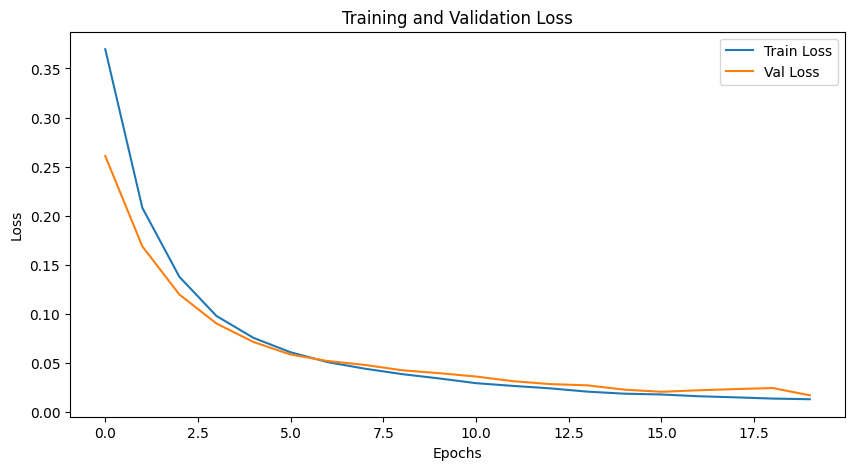

In [10]:
# Training loop
print("Starting training...")
for epoch in range(NUM_EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer, loss_fn, device, epoch+1, NUM_EPOCHS)
    val_loss = validate_one_epoch(model, val_loader, loss_fn, device, epoch+1, NUM_EPOCHS)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    summary = f"Epoch [{epoch+1}/{NUM_EPOCHS}] - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f}"
    
    if train_loss < best_train_loss:
        best_train_loss = train_loss
        
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), checkpoint_path)
        summary += f" - (Saved best model to {checkpoint_path})"
        
    print(summary)

print("\nTraining complete.")

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()


In [11]:
# Evaluation
model.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=True))
model.eval()

evaluation_dir = os.path.join(EVALUATION_DIR, f"{EXPERIMENT_ID}_notebook")
os.makedirs(evaluation_dir, exist_ok=True)

results = []
total_dice = 0.0
total_iou = 0.0
total_loss = 0.0

print("Starting evaluation...")
with torch.no_grad():
    loop = tqdm(test_loader, desc="Evaluating", leave=False)
    for i, (images, masks) in enumerate(loop):
        masks = masks.to(device)
        images_device = images.to(device)
        
        outputs = model(images_device)  # logits
        preds = predict_mask(outputs)
        
        loss = loss_fn(outputs, masks)
        total_loss += loss.item()
        
        dice, iou = calculate_metrics(preds, masks)
        total_dice += dice
        total_iou += iou
        
        results.append({
            'index': i,
            'image_path': test_dataset.data_info.loc[i, 'image_path'],
            'dice': dice,
            'iou': iou,
        })
        loop.set_postfix(dice=f"{dice:.4f}")

num_samples = len(test_loader)
avg_dice = total_dice / num_samples
avg_iou = total_iou / num_samples
avg_loss = total_loss / num_samples

print(f"Total Samples: {num_samples}")
print(f"Average Test Loss:  {avg_loss:.4f}")
print(f"Average Dice Score: {avg_dice:.4f}")
print(f"Average IoU Score:  {avg_iou:.4f}\n")


Starting evaluation...


Total Samples: 561
Average Test Loss:  0.0256
Average Dice Score: 0.7715
Average IoU Score:  0.7310



Visualizing Worst Cases:


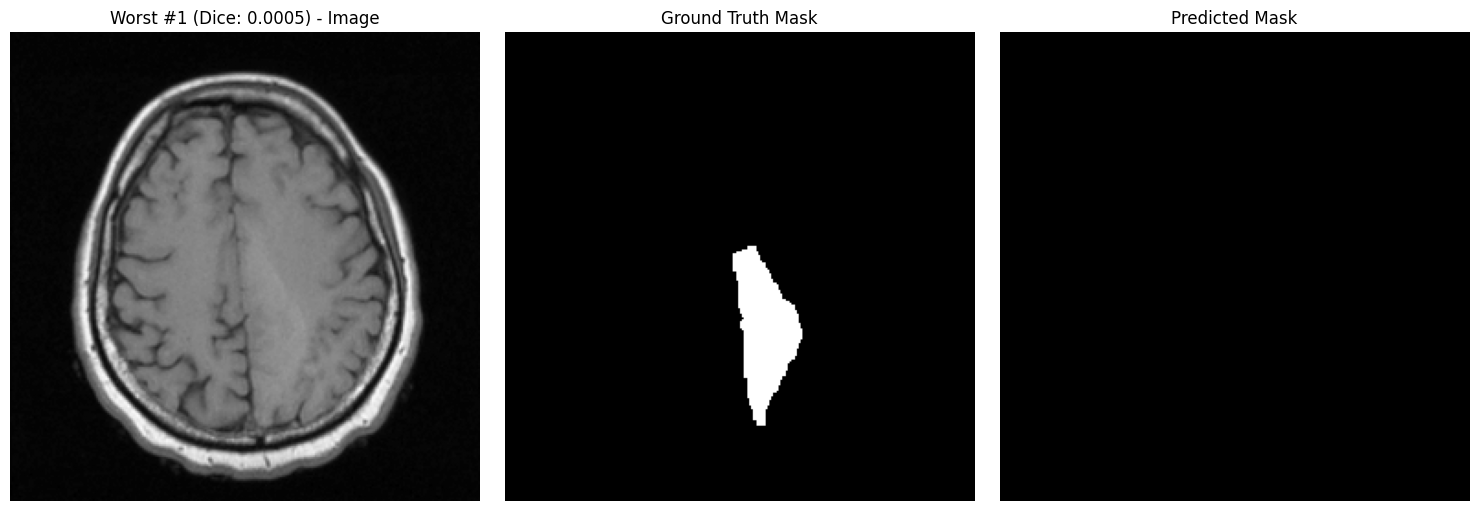

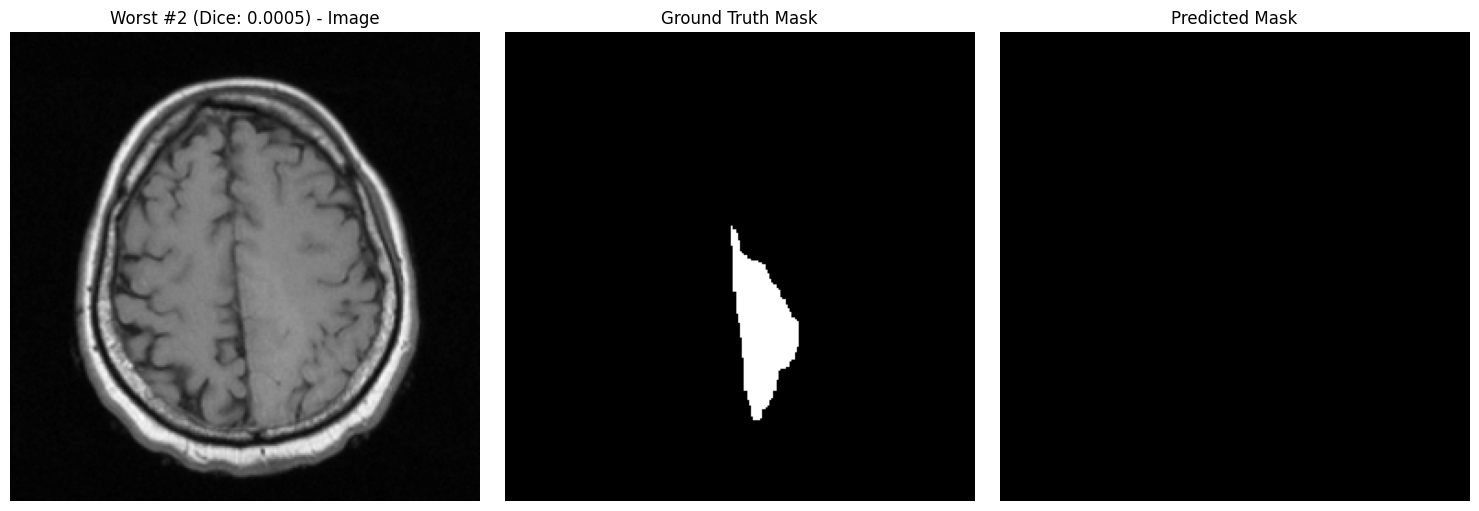

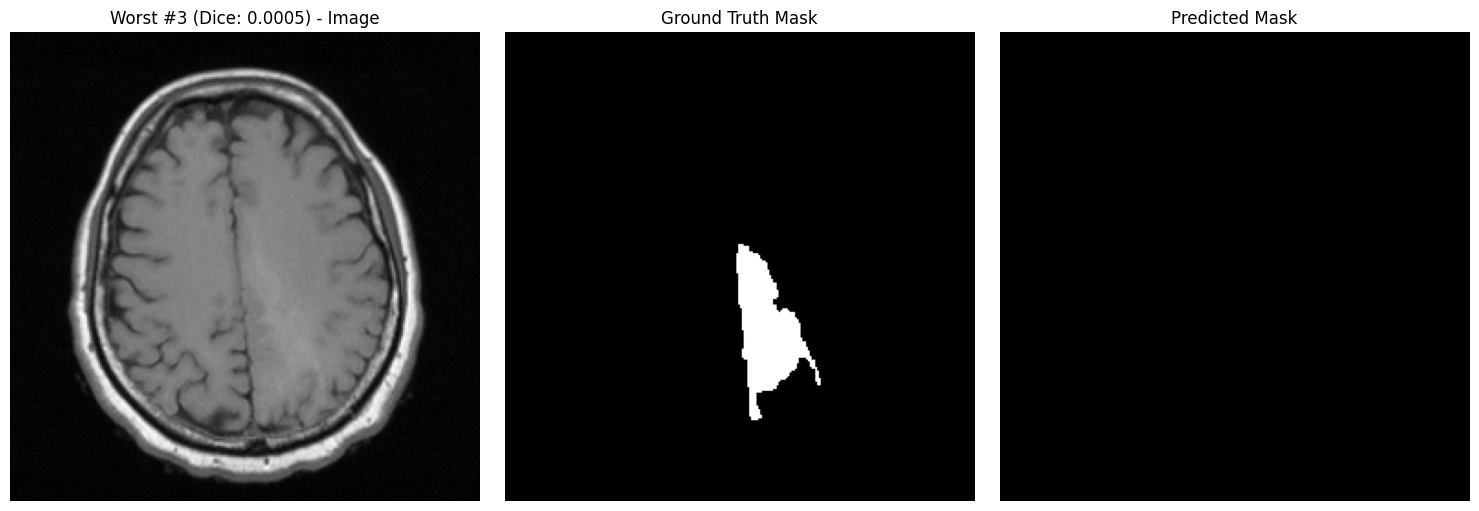

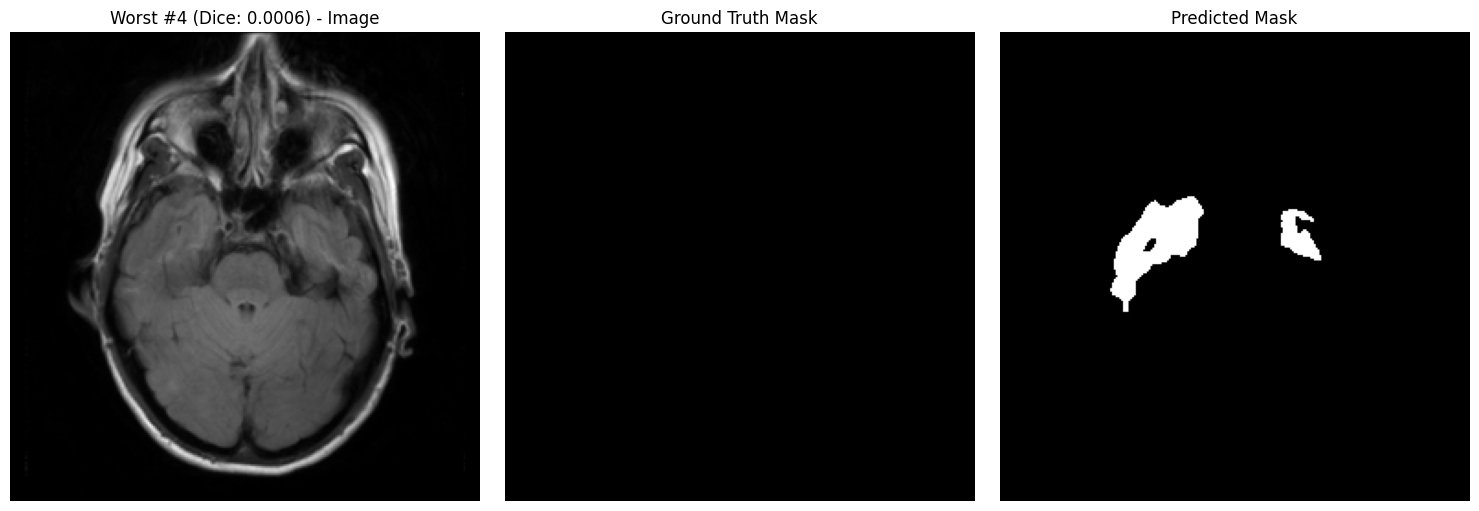

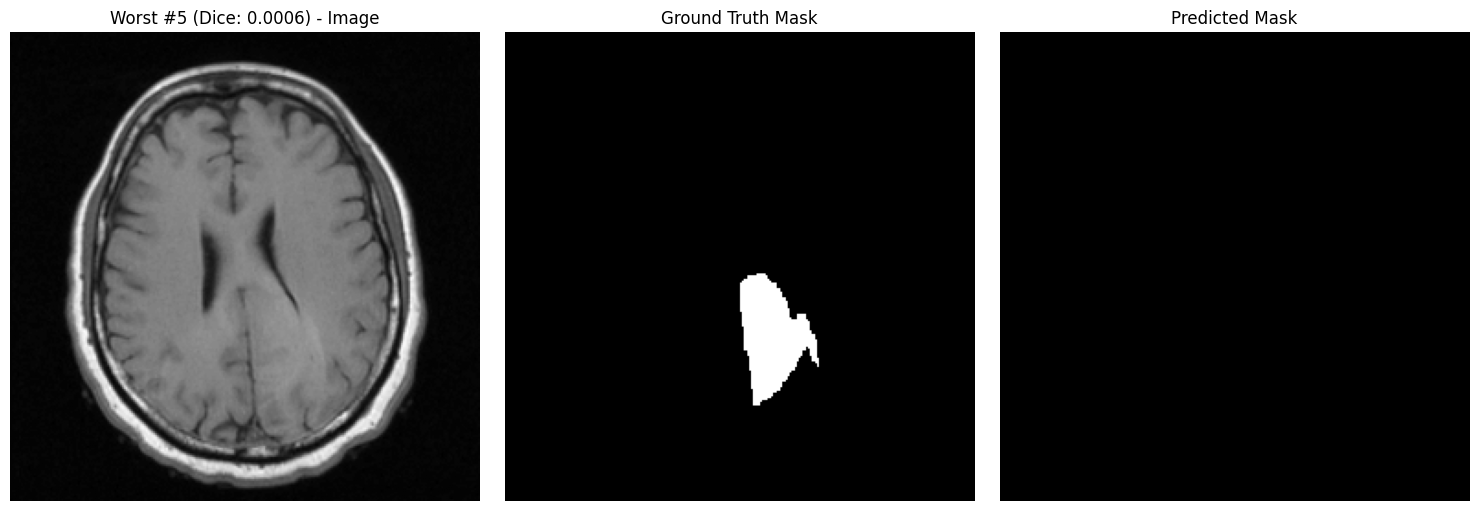

Visualizing Best Cases:


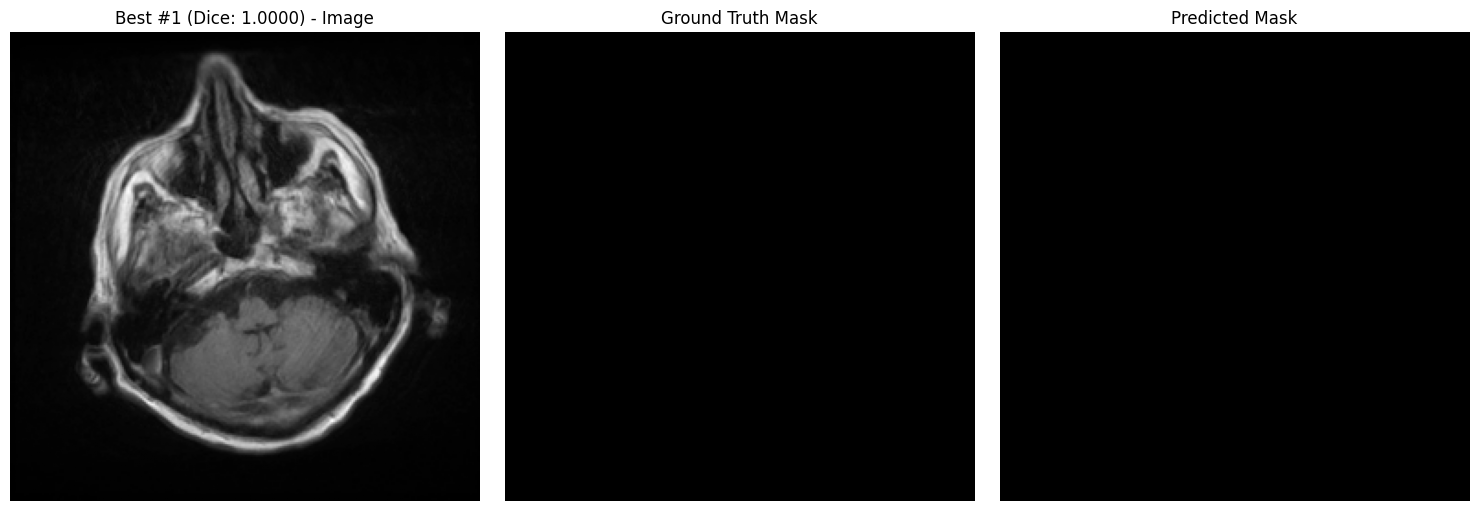

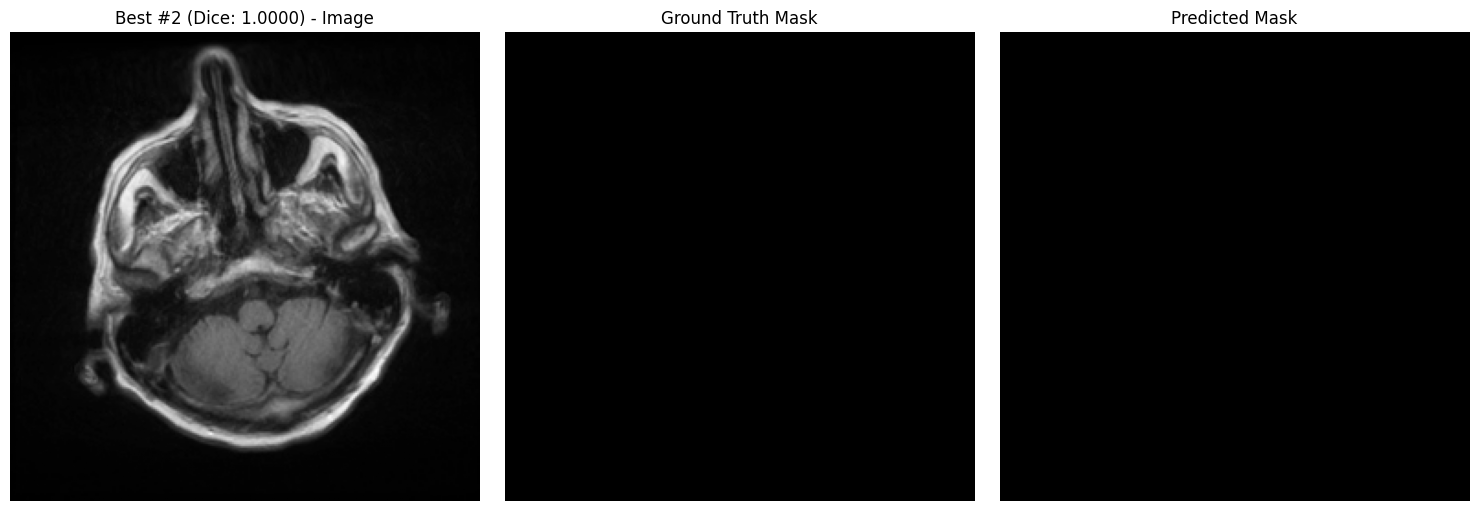

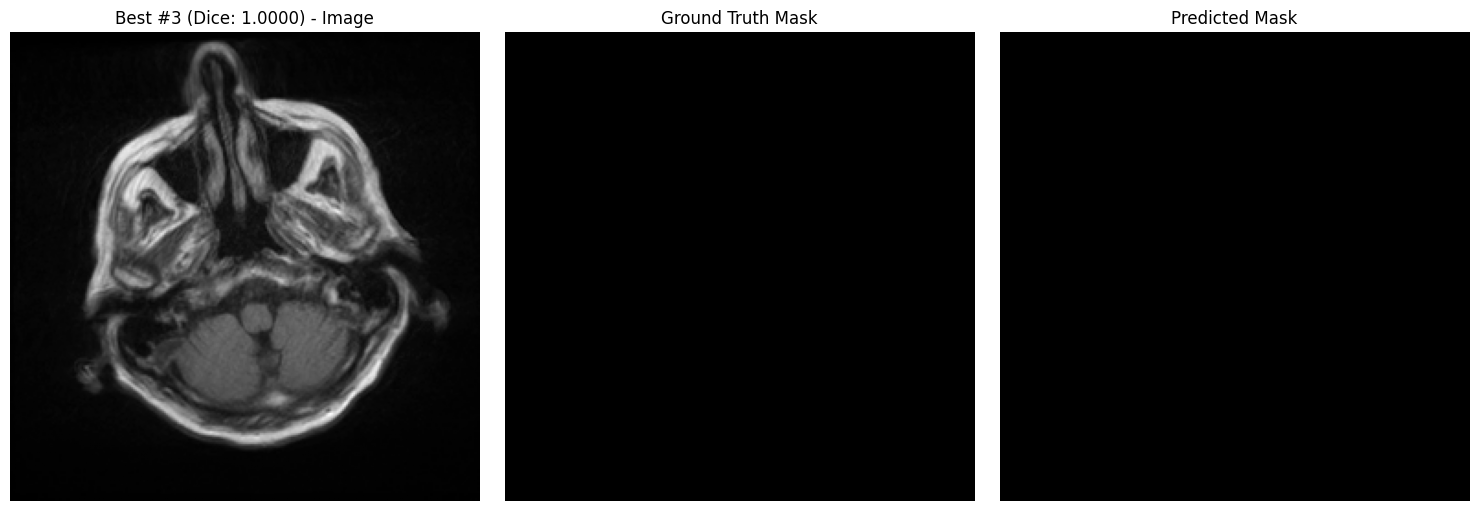

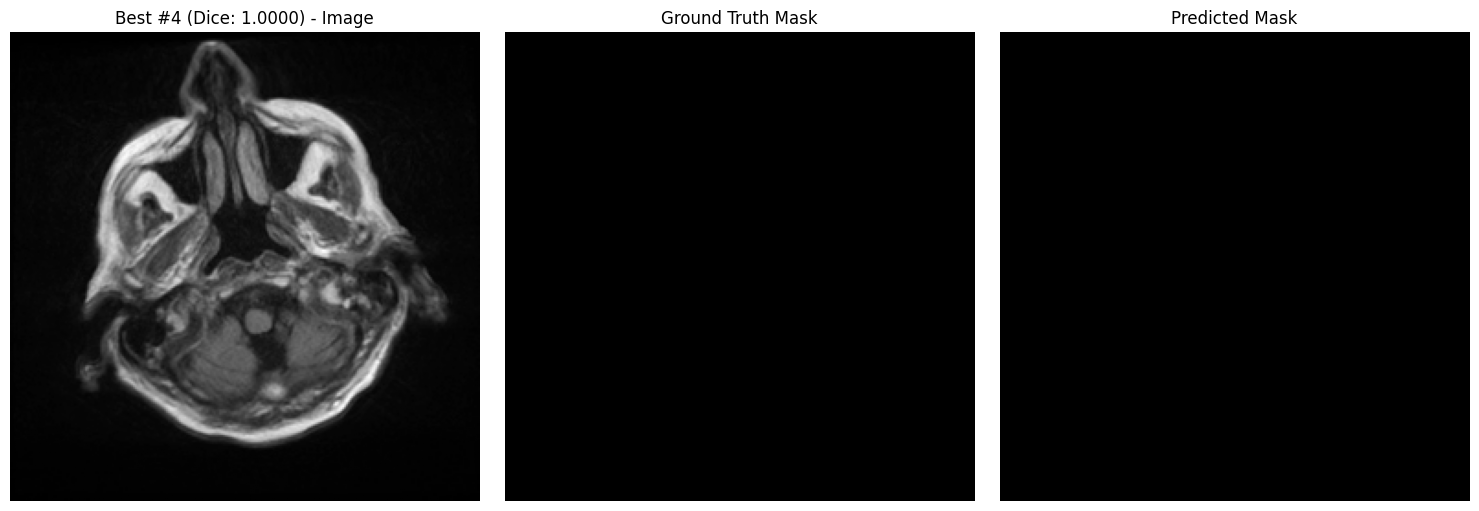

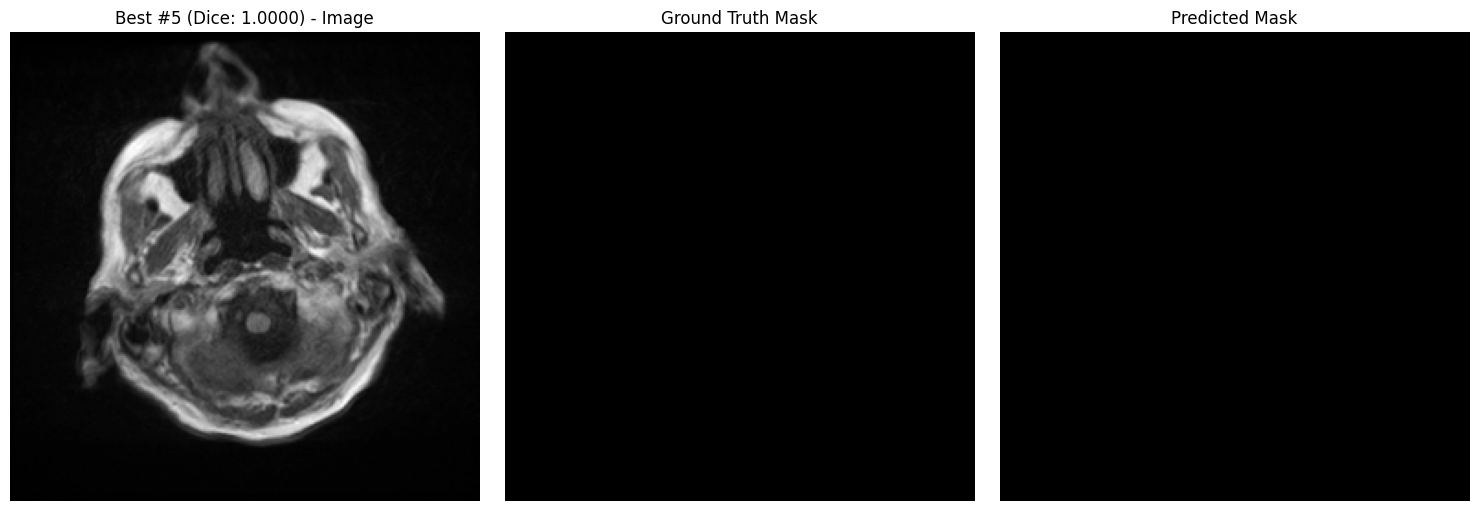

In [12]:
# Visualization of Best & Worst Predictions
results.sort(key=lambda x: x['dice'])

n_show = min(5, len(results)) 
worst_cases = results[:n_show]
best_cases = results[-n_show:]
best_cases.reverse()

def process_and_visualize(cases, prefix):
    for rank, case in enumerate(cases):
        idx = case['index']
        dice = case['dice']
        
        image, mask_true = test_dataset[idx]
        with torch.no_grad():
            img_device = image.unsqueeze(0).to(device)
            outputs = model(img_device)
            mask_pred = predict_mask(outputs).cpu().squeeze(0)
            
        save_name = f"{prefix}_{rank+1}_dice_{dice:.4f}.png"
        save_path = os.path.join(evaluation_dir, save_name)
        
        visualize_and_save(
            image, mask_true, mask_pred, 
            save_path=save_path, 
            title_prefix=f"{prefix.capitalize()} #{rank+1} (Dice: {dice:.4f})"
        )

if len(results) > 0:
    print("Visualizing Worst Cases:")
    process_and_visualize(worst_cases, "worst")
    
    unique_best = [c for c in best_cases if c not in worst_cases]
    if unique_best:
        print("Visualizing Best Cases:")
        process_and_visualize(unique_best, "best")


Visualizing Best Tumor Cases:


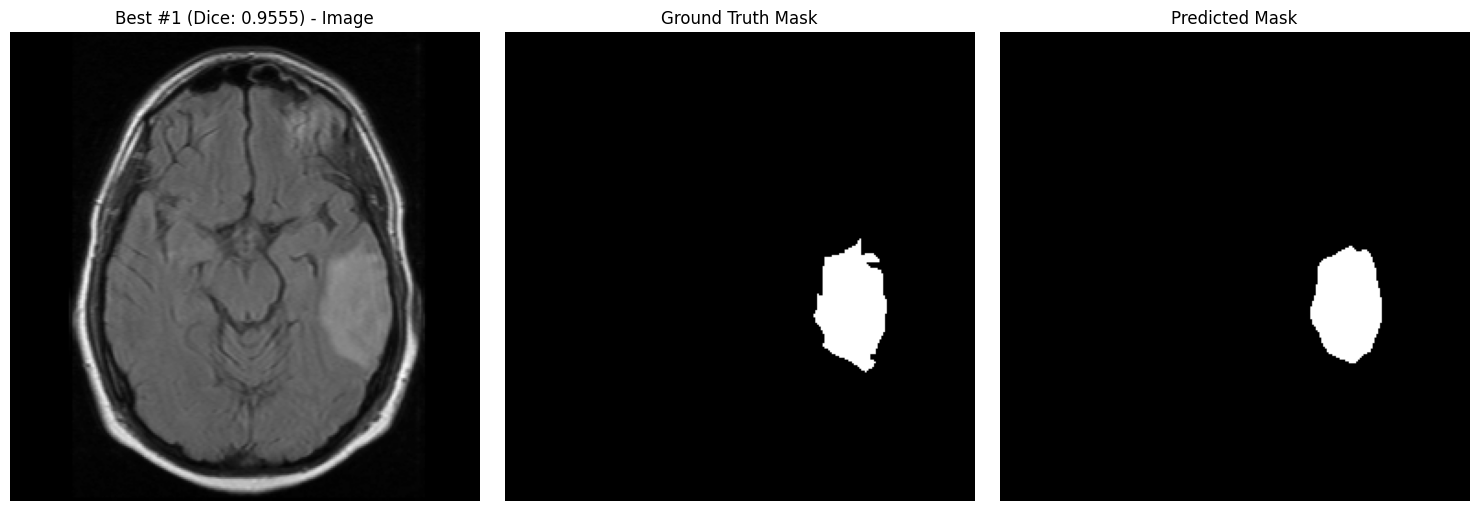

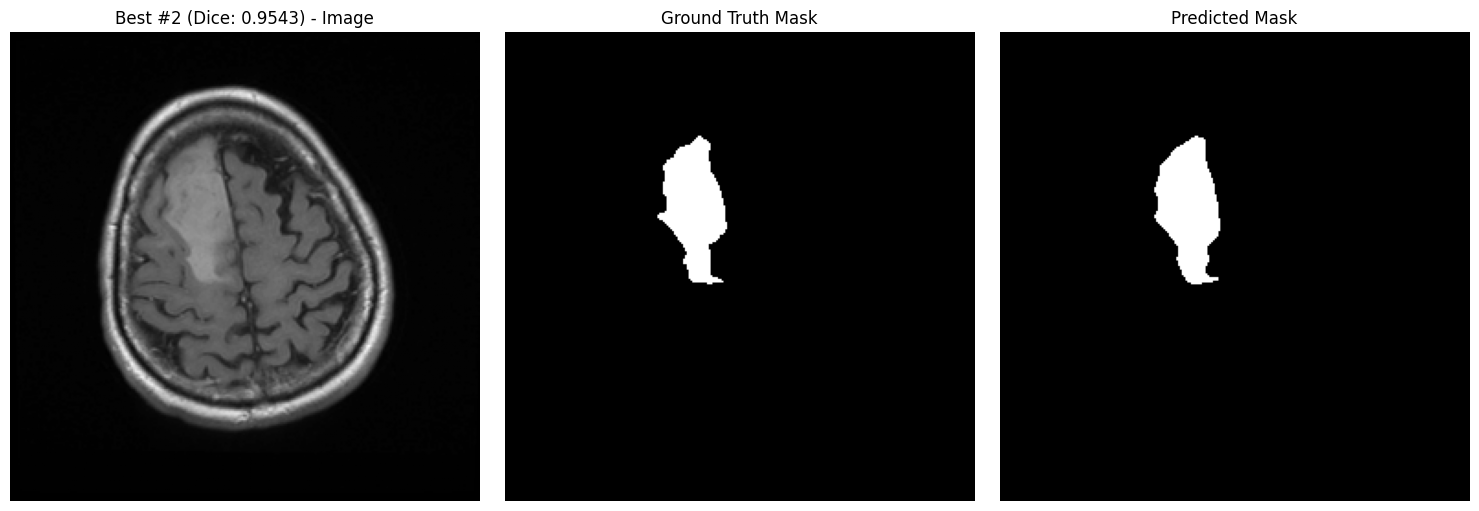

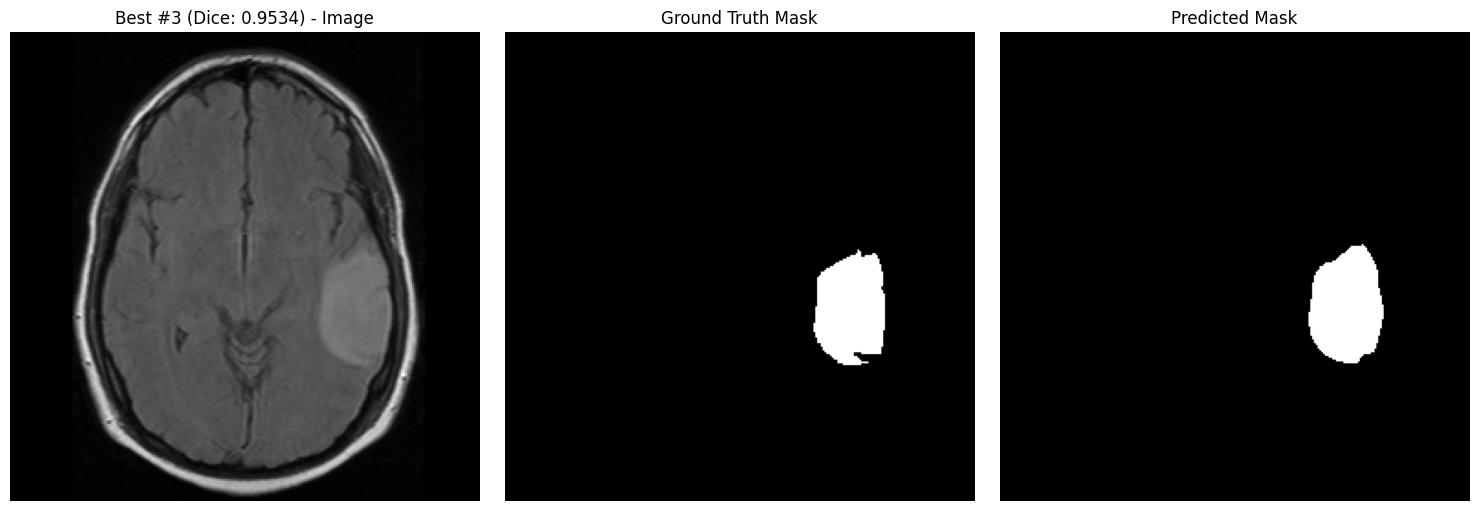

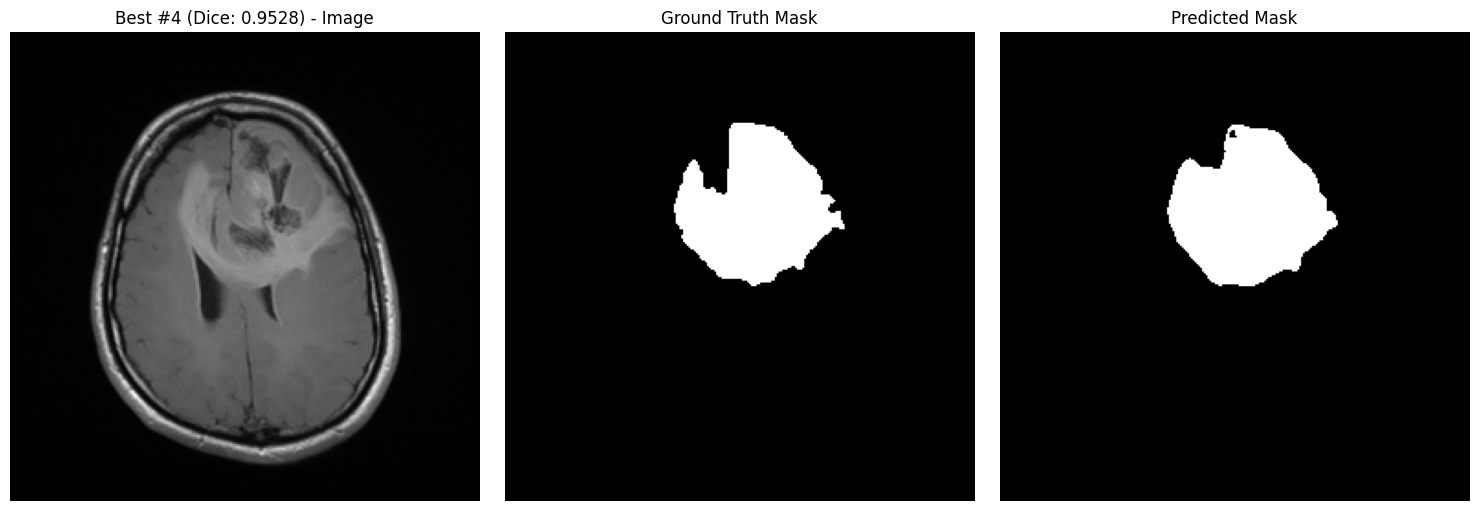

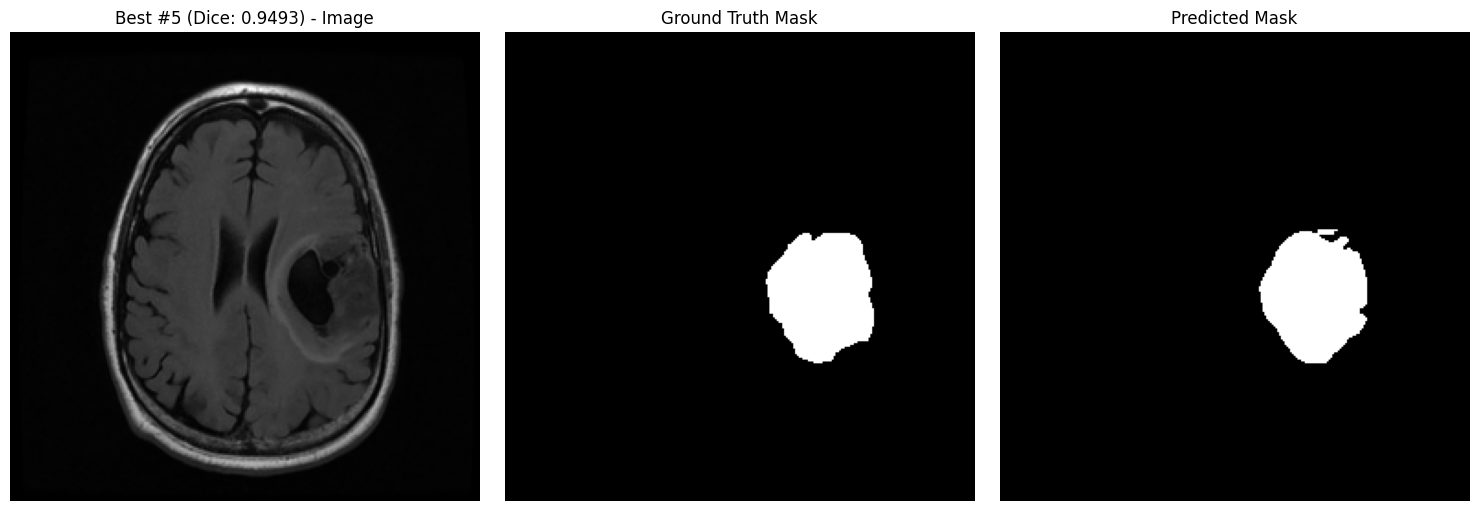

In [13]:
# Lets see the best cases when a tumor actually exists

valid_tumor_results = []
for res in results:
    idx = res['index']
    mask_path = test_dataset.data_info.loc[idx, 'mask_path'].replace("../", "")
    
    # Quick disk check to see if the mask has any white pixels
    mask_check = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask_check is not None and mask_check.max() > 0:
        valid_tumor_results.append(res)

# Sort the filtered list by dice score ascending
valid_tumor_results.sort(key=lambda x: x['dice'])
n_show = min(5, len(valid_tumor_results))
best_cases = valid_tumor_results[-n_show:]
best_cases.reverse() 

def process_and_visualize(cases, prefix):
    for rank, case in enumerate(cases):
        idx = case['index']
        dice = case['dice']
        
        image, mask_true = test_dataset[idx]
        with torch.no_grad():
            img_device = image.unsqueeze(0).to(device)
            outputs = model(img_device)
            mask_pred = predict_mask(outputs).cpu().squeeze(0)
            
        save_name = f"{prefix}_TrueTumor_{rank+1}_dice_{dice:.4f}.png"
        save_path = os.path.join(evaluation_dir, save_name)
        
        visualize_and_save(
            image, mask_true, mask_pred, 
            save_path=save_path, 
            title_prefix=f"{prefix.capitalize()} #{rank+1} (Dice: {dice:.4f})"
        )

if len(best_cases) > 0:
    print("Visualizing Best Tumor Cases:")
    process_and_visualize(best_cases, "best")
else:
    print("No valid tumor slices found in the test set")
